In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Determine change in intensity 
(to not miss residues with high line-broadening)

In [2]:
def filter_df(df):
    # Filter rows starting with 'B' and copy to avoid SettingWithCopyWarning
    filtered_df = df[df['Assign F1'].str.startswith('B')].copy()
    filtered_df['res'] = filtered_df['Assign F1'].str.split('.').str[1].astype(int)

    # Filter rows NOT starting with 'B', also copied
    unassigned_df = df[~df['Assign F1'].str.startswith('B')].copy()
    unassigned_df['label'] = unassigned_df['Assign F1'].str.extract(r'@(\d+)\.\.H')[0].astype(int)

    return filtered_df, unassigned_df

def calc_deltaI(dfP, dfPL):
    df = pd.DataFrame(dfP['res'])
    if dfP['res'].equals(dfPL['res']):  #Check that the residues are the same for all rows
        df['height_P'] = dfP['Height']
        df['height_PL'] = dfPL['Height']
        df['deltaH'] = df['height_P'] - df['height_PL']
        std_deltaH = df['deltaH'].std()
        df['deltaH_pct'] = (df['height_P'] - df['height_PL'])/df['height_P']
        std_deltaH_pct = df['deltaH_pct'].std()
        return df, std_deltaH, std_deltaH_pct

    else: print('The residue codes are not identical')


# Import intensity lists from CCPN
P = pd.read_excel('data/Peaklist_CBM92_intensities.xlsx')
PL = pd.read_excel('data/Peaklist_CBM92L6_intensities.xlsx')
P2 = pd.read_excel('data/Peaklist_CBM92_intensities_2.xlsx')
PG = pd.read_excel('data/Peaklist_CBM92G6_intensities.xlsx')

# Split intensity lists based on assigned/unassigned
filtered_df, unassigned_df = filter_df(P) # CBM92A
filtered_df_L, unassigned_df_L = filter_df(PL) # Laminarihexaose + CBM92A
filtered_df2, unassigned_df2 = filter_df(P2) # CBM92A
filtered_df_G, unassigned_df_G = filter_df(PG) # Gentiohexaose + CBM92A

# Calulate intensity change
dH_L, std_dH_L, std_dH_pct_L = calc_deltaI(filtered_df, filtered_df_L) # Laminarihexaose
dH_G, std_dH_G, std_dH_pct_G = calc_deltaI(filtered_df2, filtered_df_G) # Gentiohexaose

Residues with vey high intensity change:
87
88
89
90
130


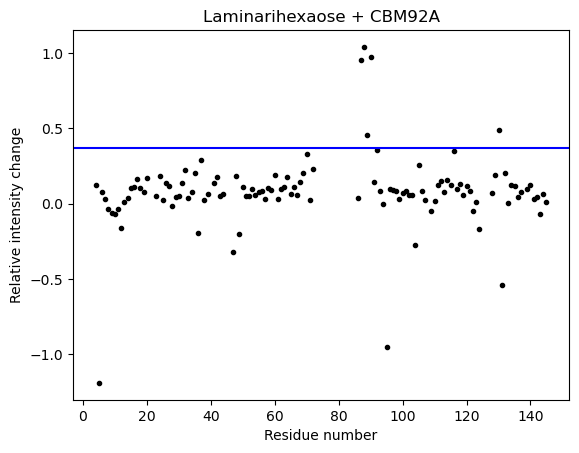

In [3]:
# Start plotting
plt.plot(dH_L['res'], dH_L['deltaH_pct'], 'k.')
plt.axhline(std_dH_pct_L*1.5, color = 'blue') 
plt.xlabel('Residue number')
plt.ylabel('Relative intensity change')
plt.title('Laminarihexaose + CBM92A')

# Determine residues with high line-broadening
print('Residues with vey high intensity change:')
high_deltaH_L = []
for res, val in zip(dH_L['res'], dH_L['deltaH_pct']):
    if val > std_dH_pct_L*1.5:
        high_deltaH_L.append(res)
        print(res)


Residues with vey high intensity change:
4
6
8
9
13
15
24
37
87
89
90
97
98
99
100
101
104
115
116
131
132
133
134
135


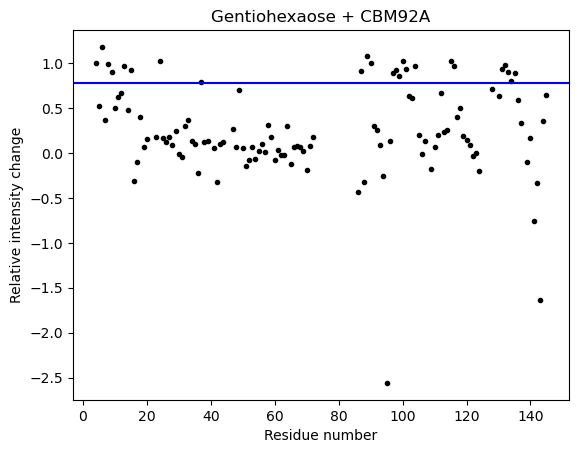

In [4]:
# Start plotting
plt.plot(dH_G['res'], dH_G['deltaH_pct'], 'k.')
plt.axhline(std_dH_pct_G*1.5, color = 'blue') 
plt.xlabel('Residue number')
plt.ylabel('Relative intensity change')
plt.title('Gentiohexaose + CBM92A')

# Determine residues with high line-broadening
print('Residues with vey high intensity change:')
high_deltaH_G = []
for res, val in zip(dH_G['res'], dH_G['deltaH_pct']):
    if val > std_dH_pct_G*1.5:
        high_deltaH_G.append(res)
        print(res)

## Plot CSP

In [5]:
#Plotting and saving figure
def plot_data(df, high_delta_H, col, filename):
    # Filter data
    df = df[~df.astype(str).apply(lambda row: row.str.contains('@')).any(axis=1)] # remove unassigned residues
    df = df.drop_duplicates() 
    df['nmrResidueCode'] = df['nmrResidueCode'].astype(int)

    THRESHOLD_1 = df['DeltaDelta'].mean()
    THRESHOLD_2 = df['DeltaDelta'].mean() + df['DeltaDelta'].std()

    # Assign colors
    GREY = '#B5B3B3'
    colors = []
    for val, res in zip(df['DeltaDelta'], df['nmrResidueCode']):
        # CSP below mean:
        if val < THRESHOLD_1 and res not in high_delta_H:
            colors.append(GREY)
        elif val < THRESHOLD_1 and res in high_delta_H:
            colors.append(col[2])
        # CSP between mean and mean+std:
        elif THRESHOLD_1 < val < THRESHOLD_2 and res not in high_delta_H:
            colors.append(col[0])
        elif THRESHOLD_1 < val < THRESHOLD_2 and res in high_delta_H:
            colors.append(col[2])
        # CSP above mean+std
        else:
            colors.append(col[1])  

    # Add colors to DF
    df['color'] = colors

    # Figure
    width_mm = 170
    width_in = width_mm / 25.4  # convert mm → inches
    height_in = width_in * 0.35 
    plt.rcParams.update({
        "font.size": 8,        # base font size
        "axes.labelsize": 8,   # axis labels
        "xtick.labelsize": 7,  # x tick labels
        "ytick.labelsize": 7,  # y tick labels
        "legend.fontsize": 7,  # legend
        })
    
    plt.figure(figsize=(width_in, height_in))
    plt.axhline(THRESHOLD_1, color=col[0], linestyle='--', linewidth = 0.8, label=f'Average = {THRESHOLD_1:.2f}')
    plt.axhline(THRESHOLD_2, color=col[1], linestyle='--', linewidth = 0.8, label=f'Average + std = {THRESHOLD_2:.2f}')
    plt.bar(df['nmrResidueCode'], df['DeltaDelta'], color = colors, width = 0.8)
    plt.xlabel('Residue number')
    plt.ylabel('$\Delta \delta$')
    plt.tight_layout()
    plt.savefig('figures/csp_'+ filename + '.png', dpi=600, bbox_inches='tight')
    plt.savefig('figures/csp_'+ filename + '.pdf', bbox_inches='tight')
    plt.savefig('figures/csp_'+ filename + '.svg', bbox_inches='tight')
    plt.show()
    
    return df

# Convert hex to rgb for PyMol
def hex_to_rgb(hexcode):
    h = hexcode.lstrip('#')
    return [round(int(h[i:i+2], 16)/255, 3) for i in (0, 2, 4)]

# Script to paste into PyMol
def make_pymol_script(df):
    # Group residues by color
    grouped = df.groupby('color')['nmrResidueCode'].apply(list).to_dict()
    
    # Build PyMOL script lines
    pymol_script = []
    for hexcode, residues in grouped.items():
        rgb = hex_to_rgb(hexcode)
        color_name = f"col_{hexcode.lstrip('#')}"
        pymol_script.append(f"set_color {color_name}, [{rgb[0]}, {rgb[1]}, {rgb[2]}]")
        residue_list = '+'.join(map(str, residues))
        pymol_script.append(f"color {color_name}, resi {residue_list}")
    
    # Print the result
    print("\n".join(pymol_script))

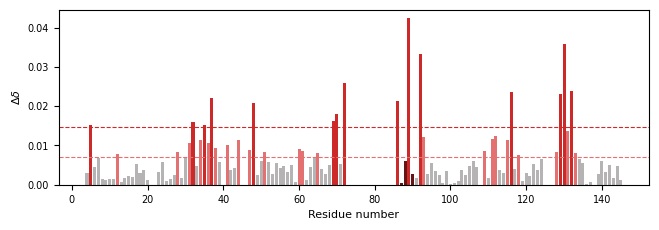

set_color col_661414, [0.4, 0.078, 0.078]
color col_661414, resi 88+90+87
set_color col_B5B3B3, [0.71, 0.702, 0.702]
color col_B5B3B3, resi 54+105+39+135+64+62+63+66+103+52+19+94+114+136+107+23+16+98+58+59+11+6+26+100+13+57+110+7+68+101+141+25+137+117+18+42+113+142+122+123+20+14+33+67+8+124+43+99+55+140+95+97+30+53+96+56+29+24+104+4+71+10+9+49+106+143+91+139+145+144+17+119+120+102+15+121+50+27+134
set_color col_CD2929, [0.804, 0.161, 0.161]
color col_CD2929, resi 130+32+116+70+72+48+5+89+132+37+129+35+86+69+92
set_color col_E37171, [0.89, 0.443, 0.443]
color col_E37171, resi 93+51+31+28+112+61+65+131+36+115+38+128+41+133+12+109+47+60+44+111+34+118


In [6]:
# Import CSP from CCPN
df_L = pd.read_excel('data/csp_lam6.xlsx', usecols = ['nmrResidueCode', 'DeltaDelta'])

# Plot and save
col_L = ['#E37171', '#CD2929', '#661414']
filename = 'laminarihexaose'
df_L = plot_data(df_L, high_deltaH_L, col_L, filename)

make_pymol_script(df_L)



In [7]:
high_deltaH_L

[87, 88, 89, 90, 130]

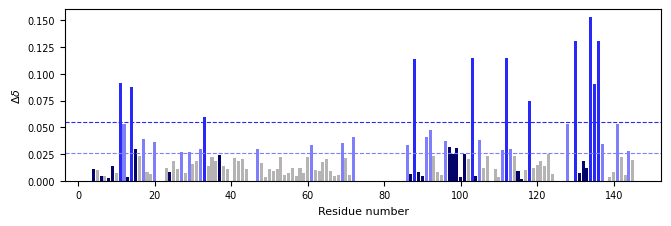

set_color col_030369, [0.012, 0.012, 0.412]
color col_030369, resi 4+6+8+9+13+15+24+37+87+89+90+97+98+99+100+101+104+115+116+131+132+133
set_color col_2828F8, [0.157, 0.157, 0.973]
color col_2828F8, resi 11+14+33+88+103+112+118+130+134+135+136
set_color col_7F7FFB, [0.498, 0.498, 0.984]
color col_7F7FFB, resi 12+17+20+27+29+32+47+61+69+72+86+91+92+96+105+111+113+128+137+141+144
set_color col_B5B3B3, [0.71, 0.702, 0.702]
color col_B5B3B3, resi 5+7+10+16+18+19+23+25+26+28+30+31+34+35+36+38+39+41+42+43+44+48+49+50+51+52+53+54+55+56+57+58+59+60+62+63+64+65+66+67+68+70+71+93+94+95+102+106+107+109+110+114+117+119+120+121+122+123+124+139+140+142+143+145


In [8]:
# Import CSP from CCPN
df_G = pd.read_excel('data/csp_gent6.xlsx', usecols = ['nmrResidueCode', 'DeltaDelta'])

# Plot and save
col_G = ['#7F7FFB', '#2828F8', '#030369']
filename = 'gentiohexaose'
df_G = plot_data(df_G, high_deltaH_G, col_G, filename)

make_pymol_script(df_G)



In [41]:
from IPython.display import HTML, display

def show_colored_sequence(sequence, df):
    """
    Display the protein sequence with residue-specific colors based on df['color'].
    - sequence: str, full protein sequence
    - df: DataFrame with columns ['nmrResidueCode', 'color']
    """
    html_seq = ""
    for i, aa in enumerate(sequence, start=1):
        # find color for this residue (default grey if missing)
        color = df.loc[df['nmrResidueCode'] == i, 'color'].values
        color = color[0] if len(color) > 0 else "#B5B3B3"
        html_seq += f"<span style='color:{color}; font-family:monospace;'>{aa}</span>"

        # line breaks every 50 residues 
        if i % 50 == 0:
            html_seq += "<br>"

    display(HTML(html_seq))

In [42]:
sequence = "MASMTGGQQMGRGSVGKTIWLQGFNNKYVNSKNGQGAMWCDSDAPQAWELFTVVDAGNGKIALRGNNGMYVSSENGEQAITCNRPAIQGWEAFDWLETADGKVSLRGSNGLFISSENGAAAMTCTRPTASGWEAFGYSVVGNALEHHHHHH"

show_colored_sequence(sequence, df_G)

In [43]:
show_colored_sequence(sequence, df_L)